Self Reflection in RAG

LLM evaluates its own output

In [15]:
import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph,END

initializing the LLM

In [16]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000267539C8A10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000267539CAAB0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

Preparing Retriever

In [17]:
docs = TextLoader("internal_doc.txt",encoding="utf-8").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
chunks = splitter.split_documents(docs)
embedding = HuggingFaceEmbeddings(model="all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(chunks,embedding)
retriever = vectorstore.as_retriever()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

State of Graph

In [18]:
class RagReflectionState(BaseModel):
    question: str
    retrieved_docs: List[Document] = []
    answer: str = ""
    reflection: str = ""
    needs_revision: bool = False
    attempts: int = 0

Node definitions

In [19]:
def retrieve_docs(state: RagReflectionState) -> RagReflectionState:
    docs = retriever.invoke(state.question)
    return state.model_copy(update={"retrieved_docs":docs})

def generate_answer(state: RagReflectionState) -> RagReflectionState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""Use the following context to answer the question:
    Context:
    {context}
    Question:
    {state.question}
    """
    answer = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer":answer,"attempts":state.attempts+1})

# self reflection node
def reflect_on_answer(state: RagReflectionState) -> RagReflectionState:
    prompt = f"""Reflect on the following answer to see if it fully addresses the question.
    State YES if it is complete and correct, or NO with an explanation.
    Question: {state.question}
    Answer: {state.answer}
    Respond like:
    Reflection: YES or NO
    Explanation: ...
    """
    result = llm.invoke(prompt).content
    is_ok = "reflection: yes" in result.lower()
    return state.model_copy(update={"reflection":result,"needs_revision": not is_ok})

In [20]:
def finalizer(state: RagReflectionState) -> RagReflectionState:
    return state

Building the graph

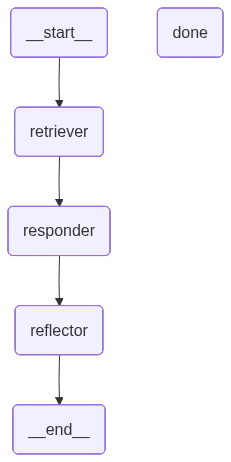

In [21]:
builder = StateGraph(RagReflectionState)

builder.add_node("retriever",retrieve_docs)
builder.add_node("responder",generate_answer)
builder.add_node("reflector",reflect_on_answer)
builder.add_node("done",finalizer)

builder.set_entry_point("retriever")
builder.add_edge("retriever","responder")
builder.add_edge("responder","reflector")
builder.add_conditional_edges(
    "reflector",
    lambda s: "done" if not s.needs_revision or s.attempts>=2 else "retriever"
)
builder.add_edge("done",END)
graph = builder.compile()
graph

testing the RAG

In [27]:
query = "What operating system do the application servers run?"
state = RagReflectionState(question=query)
result = graph.invoke(state)
print(f"Question: {query}")
print(f"Answer: {result['answer']}")
print(f"Attempts: {result['attempts']}")

Question: What operating system do the application servers run?
Answer: Unfortunately, the information provided does not mention the operating system of the application servers. The Server Inventory section only lists the servers but does not specify the operating system for any of them.
Attempts: 2


In [28]:
query = "Which section talks about deployment infrastructure?"
state = RagReflectionState(question=query)
for event in graph.stream(state,stream_mode="updates"):
    print(event)

{'retriever': {'question': 'Which section talks about deployment infrastructure?', 'retrieved_docs': [Document(id='1448e07d-81b7-4f24-921e-cecce2dbf639', metadata={'source': 'internal_doc.txt'}, page_content='INTERNAL DOCUMENT - CONFIDENTIAL\n\nDepartment: Engineering\n\nSprint Backlog\n\n- Refactor auth module.\n- Fix cache invalidation bug.\n- Update API gateway configuration.\n- Rotate service account credentials.\n- Complete migration to PostgreSQL 16.\n- Add distributed tracing for payment services.\n- Implement request rate limiting.\n- Optimize image processing pipeline.\n- Upgrade Kubernetes cluster to v1.33.\n- Remove deprecated authentication endpoints.\n\nServer Inventory'), Document(id='b82abbe6-e2d9-4205-a1ce-2d959adbcc81', metadata={'source': 'internal_doc.txt'}, page_content='Secondary\n- Frankfurt\n- Virginia\n\nCI/CD Pipeline\n\n1. Pull Request\n2. Unit Tests\n3. Integration Tests\n4. Docker Build\n5. Security Scan\n6. Staging Deployment\n7. Manual Approval\n8. Product